In [1]:
import sys

sys.path.append("..")

In [2]:
import numpy as np
from matplotlib import colors
from matplotlib import pyplot as plt
from matplotlib.pyplot import colormaps

In [3]:
Bfield = np.load("../data/bfieldim.npy")
e_density = np.load("../data/edensity.npy").T

In [4]:
divergent_cmap = colormaps["RdBu_r"]

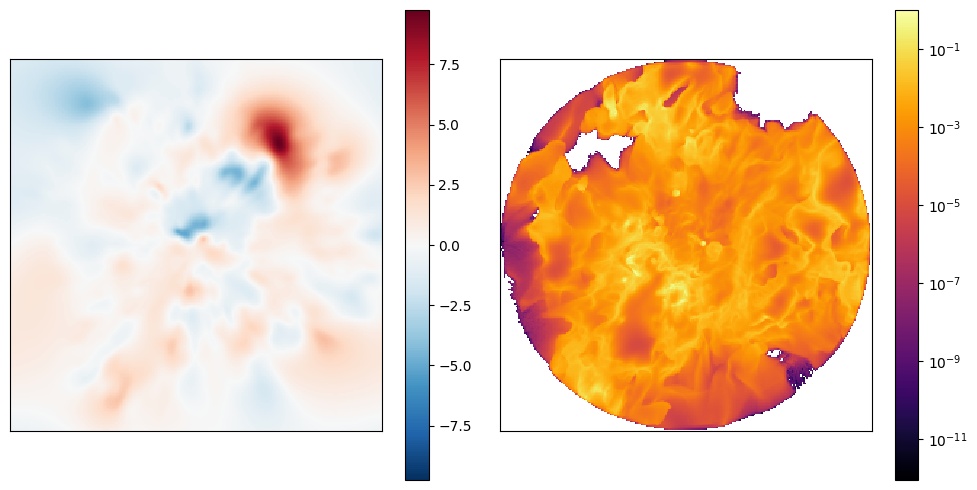

In [5]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

ax = axes[0]
mesh = ax.pcolormesh(Bfield, cmap=divergent_cmap, norm=colors.CenteredNorm())
fig.colorbar(mesh, ax=ax)

ax = axes[1]
mesh = ax.pcolormesh(e_density, cmap="inferno", norm=colors.LogNorm())
fig.colorbar(mesh, ax=ax)

fig.tight_layout()

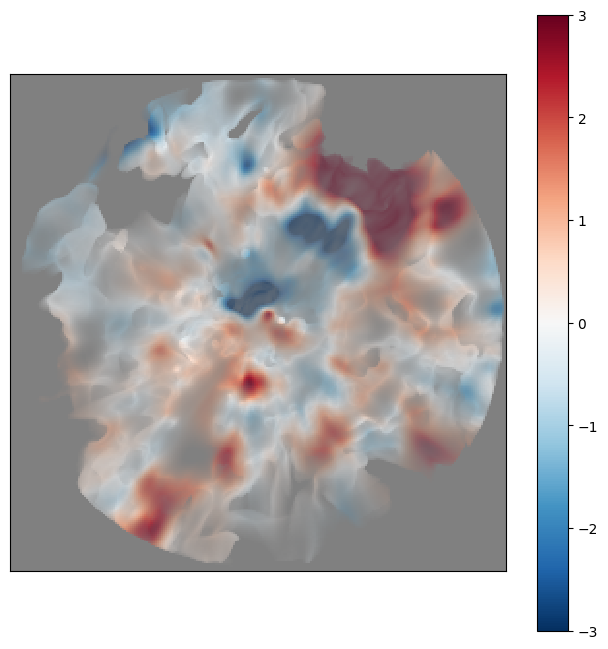

In [6]:
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor("gray")

norm = colors.CenteredNorm(vcenter=0, halfrange=3.0)
alpha = colors.LogNorm(vmin=1e-5, clip=True)(e_density)
mesh = ax.pcolormesh(divergent_cmap(norm(Bfield), alpha=alpha))
# mesh = ax.pcolormesh(colormaps['inferno'](lognorm(e_density)))

fig.colorbar(ScalarMappable(cmap=divergent_cmap, norm=norm), ax=ax)

In [12]:
import scipy
import scipy.interpolate

from colorpalettes.color import Color

B_min = Color.blue()
B_0 = Color.white()
B_max = Color.red()

unknown = Color.black()

e_density_norm = colors.LogNorm(vmin=1e-5, vmax=np.max(e_density), clip=True)


def lerp(start: Color, end: Color, t: float) -> Color:
    start_ = np.array(start.CAM02UCS)
    end_ = np.array(end.CAM02UCS)
    return Color.from_CAM02UCS(tuple(start_ + t * (end_ - start_)))


def get_color(B: float, e_density: float) -> Color:
    B = min(max(B, -3.0), 3.0)
    sat = e_density_norm(e_density)
    col_min = lerp(unknown, B_min, sat)
    col_0 = lerp(unknown, B_0, sat)
    col_max = lerp(unknown, B_max, sat)
    B_color_spline = scipy.interpolate.CubicSpline(
        x=[-3.0, 0.0, 3.0],
        y=np.array(
            [
                col_min.CAM02UCS,
                col_0.CAM02UCS,
                col_max.CAM02UCS,
            ]
        ),
    )
    return Color.from_CAM02UCS(tuple(B_color_spline(B)))

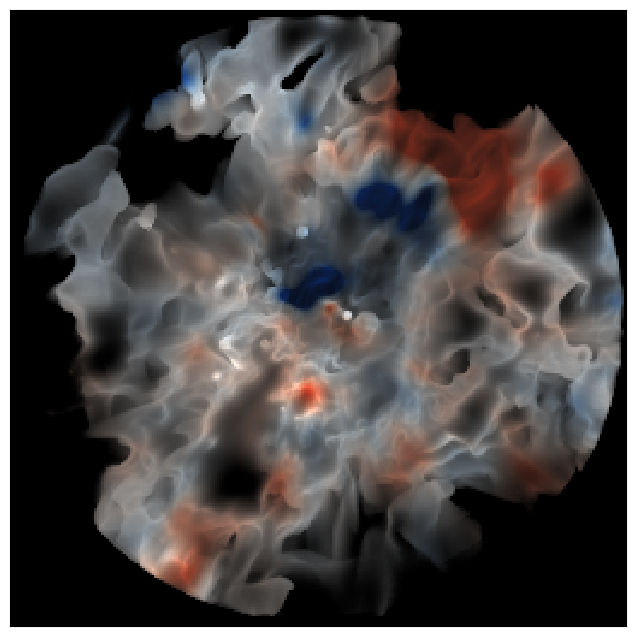

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

pixel_colors = [get_color(B, n_e).rgb for B, n_e in zip(Bfield.flatten(), e_density.flatten())]
mesh = ax.pcolormesh(np.array(pixel_colors).reshape((*Bfield.shape, 3)))
# mesh = ax.pcolormesh(colormaps['inferno'](lognorm(e_density)))